# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

Мы научимся обрабатывать пропуски в данных для количественных (числовых) и категориальных признаков и масштабировать данные. Также мы научимся преобразовывать категориальные признаки в числовые.

### В чем состоит проблема?

- Если в данных есть пропуски, то большинство алгоритмов машинного обучения не будут с ними работать. Даже корреляционная матрица не будет строиться корректно.
- Большинство алгоритмов машинного обучения требуют явного перекодирования категориальных признаков в числовые. Даже если алгоритм не требует этого явно, такое перекодирование возможно стоит попробовать, чтобы повысить качество модели.
- Большинство алгоритмов показывает лучшее качество на масштабированных признаках, в особенности алгоритмы, использующие методы градиентного спуска.


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

Используем данные о зп [Salary_Data](https://www.kaggle.com/datasets/mohithsairamreddy/salary-data)

In [162]:
# Будем использовать только обучающую выборку
data = pd.read_csv('data/Salary_Data.csv', sep=",")

In [163]:
# размер набора данных
data.shape

(6704, 6)

In [164]:
# типы колонок
data.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

In [165]:
# проверим есть ли пропущенные значения
data.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [166]:
# Первые 5 строк датасета
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [167]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 6704


# Обработка пропусков в данных

## Простые стратегии - удаление или заполнение нулями

Удаление колонок, содержащих пустые значения
`res = data.dropna(axis=1, how='any')`

Удаление строк, содержащих пустые значения
`res = data.dropna(axis=0, how='any')`

[Документация](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html)

**Удаление может производиться для группы строк или колонок.**

In [168]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((6704, 6), (6704, 0))

In [169]:
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((6704, 6), (6698, 6))

In [170]:
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [171]:
# Заполнение всех пропущенных значений нулями
# В данном случае это некорректно, так как нулями заполняются в том числе категориальные колонки
data_new_3 = data.fillna(0)
data_new_3.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## "Внедрение значений" - импьютация (imputation)

### Обработка пропусков в числовых данных

In [172]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 2, 0.03%.
Колонка Years of Experience. Тип данных float64. Количество пустых значений 3, 0.04%.
Колонка Salary. Тип данных float64. Количество пустых значений 5, 0.07%.


In [173]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0
...,...,...,...
6699,49.0,20.0,200000.0
6700,32.0,3.0,50000.0
6701,30.0,4.0,55000.0
6702,46.0,14.0,140000.0


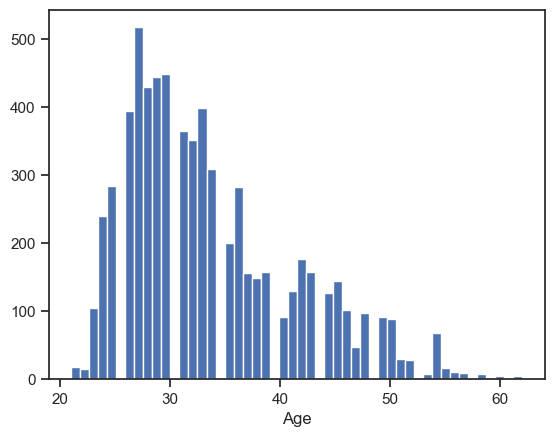

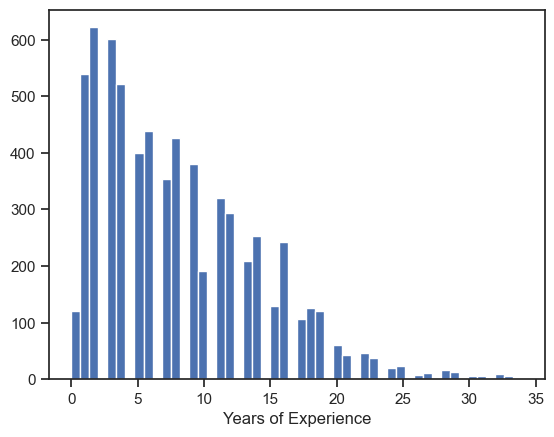

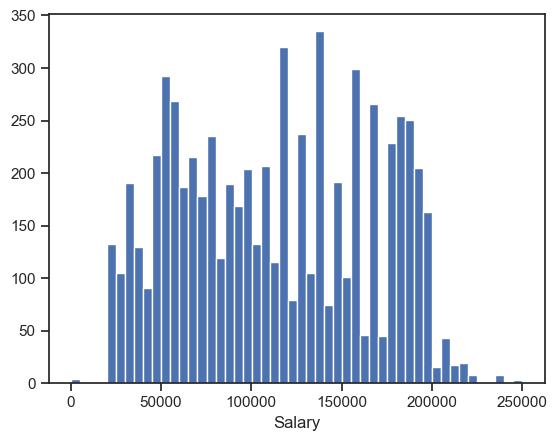

In [174]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

Будем использовать встроенные средства импьютации библиотеки scikit-learn - https://scikit-learn.org/stable/modules/impute.html

In [175]:
data_num_age = data_num[['Age']]
data_num_age.head()

,Age
0,32.0
1,28.0
2,45.0
3,36.0
4,52.0


In [176]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [177]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_age)
mask_missing_values_only

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(6704, 1))

С помощью класса [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer) можно проводить импьютацию различными [показателями центра распределения](https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%BA%D0%B0%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D0%B8_%D1%86%D0%B5%D0%BD%D1%82%D1%80%D0%B0_%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F)

In [178]:
strategies=['mean', 'median', 'most_frequent']

In [179]:
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_age)
    return data_num_imp[mask_missing_values_only]

In [180]:
strategies[0], test_num_impute(strategies[0])

('mean', array([33.62085944, 33.62085944]))

In [181]:
strategies[1], test_num_impute(strategies[1])

('median', array([32., 32.]))

In [182]:
strategies[2], test_num_impute(strategies[2])

('most_frequent', array([27., 27.]))

In [183]:
# Более сложная функция, которая позволяет задавать колонку и вид импьютации
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [184]:
data[['Years of Experience']].describe()

,Years of Experience
count,6701.000000
mean,8.094687
std,6.059003
min,0.000000
25%,3.000000
50%,7.000000
75%,12.000000
max,34.000000


In [185]:
test_num_impute_col(data, 'Years of Experience', strategies[0])

('Years of Experience',
 'mean',
 3,
 np.float64(8.094687360095508),
 np.float64(8.094687360095508))

In [186]:
test_num_impute_col(data, 'Years of Experience', strategies[1])

('Years of Experience', 'median', 3, np.float64(7.0), np.float64(7.0))

In [187]:
test_num_impute_col(data, 'Years of Experience', strategies[2])

('Years of Experience', 'most_frequent', 3, np.float64(2.0), np.float64(2.0))

### Обработка пропусков в категориальных данных

In [188]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    cat_cols.append(col)
    temp_perc = round((temp_null_count / total_count) * 100.0, 2)
    print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 2, 0.03%.
Колонка Gender. Тип данных object. Количество пустых значений 2, 0.03%.
Колонка Education Level. Тип данных object. Количество пустых значений 3, 0.04%.
Колонка Job Title. Тип данных object. Количество пустых значений 2, 0.03%.
Колонка Years of Experience. Тип данных float64. Количество пустых значений 3, 0.04%.
Колонка Salary. Тип данных float64. Количество пустых значений 5, 0.07%.


**Какие из этих колонок Вы бы выбрали или не выбрали для построения модели?**

Для построения модели я бы выбрал Education Level, Job Title, Years of Experience, Salary. Остальные - либо не вносят принципиально новой информации, либо избыточны.
Класс SimpleImputer можно использовать для категориальных признаков со стратегией "mean" и "most frequent".

In [189]:
cat_temp_data = data[['Education Level']]
cat_temp_data.head()

,Education Level
0,Bachelor's
1,Master's
2,PhD
3,Bachelor's
4,Master's


In [190]:
cat_temp_data['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', nan, "Bachelor's Degree",
       "Master's Degree", 'High School', 'phD'], dtype=object)

In [191]:
cat_temp_data[cat_temp_data['Education Level'].isnull()].shape

(3, 1)

In [192]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([["Bachelor's"],
       ["Master's"],
       ['PhD'],
       ...,
       ["Bachelor's Degree"],
       ["Master's Degree"],
       ['High School']], shape=(6704, 1), dtype=object)

In [193]:
# Пустые значения отсутствуют
np.unique(data_imp2)

array(["Bachelor's", "Bachelor's Degree", 'High School', "Master's",
       "Master's Degree", 'PhD', 'phD'], dtype=object)

In [194]:
# Импьютация константой
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([["Bachelor's"],
       ["Master's"],
       ['PhD'],
       ...,
       ["Bachelor's Degree"],
       ["Master's Degree"],
       ['High School']], shape=(6704, 1), dtype=object)

In [195]:
np.unique(data_imp3)

array(["Bachelor's", "Bachelor's Degree", 'High School', "Master's",
       "Master's Degree", 'NA', 'PhD', 'phD'], dtype=object)

In [196]:
data_imp3[data_imp3=='NA'].size

3

# Преобразование категориальных признаков в числовые

In [197]:
cat_enc = pd.DataFrame({'c1':data_imp2.T[0]})
cat_enc

,c1
0,Bachelor's
1,Master's
2,PhD
3,Bachelor's
4,Master's
...,...
6699,PhD
6700,High School
6701,Bachelor's Degree
6702,Master's Degree


## Кодирование категорий целочисленными значениями (label encoding)

В этом случае уникальные значения категориального признака кодируются целыми числами.

В scikit-learn для такого кодирования используется два класса :

- [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) - который ориентирован на применение к одному признаку. Этот класс прежде всего предназначен для кодирования целевого признака, но может быть также использован для последовательного кодирования отдельных нецелевых признаков.
- [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) - который ориентирован на применение к матрице объект-признак, то есть для кодирования матрицы нецелевых признаков.

### Использование LabelEncoder

In [198]:
from sklearn.preprocessing import LabelEncoder

In [199]:
cat_enc['c1'].unique()

array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", 'High School', 'phD'], dtype=object)

In [200]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

In [201]:
# Наименования категорий в соответствии с порядковыми номерами

# Свойство называется classes, потому что предполагается что мы решаем 
# задачу классификации и каждое значение категории соответствует 
# какому-либо классу целевого признака

le.classes_

array(["Bachelor's", "Bachelor's Degree", 'High School', "Master's",
       "Master's Degree", 'PhD', 'phD'], dtype=object)

In [202]:
cat_enc_le

array([0, 3, 5, ..., 1, 4, 2], shape=(6704,))

In [203]:
np.unique(cat_enc_le)

array([0, 1, 2, 3, 4, 5, 6])

In [204]:
# В этом примере видно, что перед кодированием 
# уникальные значения признака сортируются в лексикографиеском порядке
le.inverse_transform([0, 1, 2])

array(["Bachelor's", "Bachelor's Degree", 'High School'], dtype=object)

### Использование OrdinalEncoder

In [205]:
from sklearn.preprocessing import OrdinalEncoder

In [206]:
data_oe = data[['Gender', 'Education Level', 'Job Title', ]]
data_oe.head()

,Gender,Education Level,Job Title
0,Male,Bachelor's,Software Engineer
1,Female,Master's,Data Analyst
2,Male,PhD,Senior Manager
3,Female,Bachelor's,Sales Associate
4,Male,Master's,Director


In [207]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['Male', "Bachelor's", 'Software Engineer'],
       ['Female', "Master's", 'Data Analyst'],
       ['Male', 'PhD', 'Senior Manager'],
       ...,
       ['Female', "Bachelor's Degree", 'Financial Manager'],
       ['Male', "Master's Degree", 'Marketing Manager'],
       ['Female', 'High School', 'Sales Executive']],
      shape=(6704, 3), dtype=object)

In [208]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[  1.,   0., 178.],
       [  0.,   3.,  18.],
       [  1.,   6., 146.],
       ...,
       [  0.,   1.,  42.],
       [  1.,   4.,  97.],
       [  0.,   2., 119.]], shape=(6704, 3))

In [209]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([0., 1., 2., 3.])

In [210]:
# Уникальные значения 2 признака
np.unique(cat_enc_oe[:, 1])

array([0., 1., 2., 3., 4., 5., 6., 7.])

In [211]:
# Уникальные значения 3 признака
np.unique(cat_enc_oe[:, 2])

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

In [212]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['Female', 'Male', 'NA', 'Other'], dtype=object),
 array(["Bachelor's", "Bachelor's Degree", 'High School', "Master's",
        "Master's Degree", 'NA', 'PhD', 'phD'], dtype=object),
 array(['Account Manager', 'Accountant', 'Administrative Assistant',
        'Back end Developer', 'Business Analyst',
        'Business Development Manager', 'Business Intelligence Analyst',
        'CEO', 'Chief Data Officer', 'Chief Technology Officer',
        'Content Marketing Manager', 'Copywriter', 'Creative Director',
        'Customer Service Manager', 'Customer Service Rep',
        'Customer Service Representative', 'Customer Success Manager',
        'Customer Success Rep', 'Data Analyst', 'Data Entry Clerk',
        'Data Scientist', 'Delivery Driver', 'Developer',
        'Digital Content Producer', 'Digital Marketing Manager',
        'Digital Marketing Specialist', 'Director',
        'Director of Business Development', 'Director of Data Science',
        'Director of Engineering', 

In [213]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)

array([['Male', "Bachelor's", 'Software Engineer'],
       ['Female', "Master's", 'Data Analyst'],
       ['Male', 'PhD', 'Senior Manager'],
       ...,
       ['Female', "Bachelor's Degree", 'Financial Manager'],
       ['Male', "Master's Degree", 'Marketing Manager'],
       ['Female', 'High School', 'Sales Executive']],
      shape=(6704, 3), dtype=object)

### Проблемы использования LabelEncoder и OrdinalEncoder

Необходимо отметить, что LabelEncoder и OrdinalEncoder могут использоваться только для категориальных признаков в номинальных шкалах (для которых отсутствует порядок), например города, страны, названия рек и т.д. 

Это связано с тем, что задать какой-либо порядок при кодировании с помощью LabelEncoder и OrdinalEncoder невозможно, они сортируют категории в лексикографическом порядке.

При этом кодирование целыми числами создает фиктивное отношение порядка (1 < 2 < 3 < ...) которого не было в исходных номинальных шкалах. Данное отношение порядка может негативно повлиять на построение модели машинного обучения.

### Кодирование шкал порядка

Библиотека scikit-learn не предоставляет готового решения для кодирования шкал порядка, но можно воспользоваться [функцией map для отдельных объектов Series.](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)

In [214]:
# пример шкалы порядка 'small' < 'medium' < 'large'
sizes = ['small', 'medium', 'large', 'small', 'medium', 'large', 'small', 'medium', 'large']

In [215]:
pd_sizes = pd.DataFrame(data={'sizes':sizes})
pd_sizes

,sizes
0,small
1,medium
2,large
3,small
4,medium
5,large
6,small
7,medium
8,large


In [216]:
pd_sizes['sizes_codes'] = pd_sizes['sizes'].map({'small':1, 'medium':2, 'large':3})
pd_sizes

,sizes,sizes_codes
0,small,1
1,medium,2
2,large,3
3,small,1
4,medium,2
5,large,3
6,small,1
7,medium,2
8,large,3


In [217]:
pd_sizes['sizes_decoded'] = pd_sizes['sizes_codes'].map({1:'small', 2:'medium', 3:'large'})
pd_sizes

,sizes,sizes_codes,sizes_decoded
0,small,1,small
1,medium,2,medium
2,large,3,large
3,small,1,small
4,medium,2,medium
5,large,3,large
6,small,1,small
7,medium,2,medium
8,large,3,large


## Кодирование категорий наборами бинарных значений - [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

В этом случае каждое уникальное значение признака становится новым отдельным признаком.

In [218]:
from sklearn.preprocessing import OneHotEncoder

In [219]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['c1']])

In [220]:
cat_enc.shape

(6704, 1)

In [221]:
cat_enc_ohe.shape

(6704, 7)

In [222]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6704 stored elements and shape (6704, 7)>

In [223]:
cat_enc_ohe.todense()[0:10]

matrix([[1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0.]])

In [224]:
cat_enc.head(10)

,c1
0,Bachelor's
1,Master's
2,PhD
3,Bachelor's
4,Master's
5,Bachelor's
6,Master's
7,Bachelor's
8,Bachelor's
9,PhD


## [Pandas get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) - быстрый вариант one-hot кодирования

In [225]:
pd.get_dummies(cat_enc).head()

,c1_Bachelor's,c1_Bachelor's Degree,c1_High School,c1_Master's,c1_Master's Degree,c1_PhD,c1_phD
0,True,False,False,False,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,False,False,True,False
3,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False


In [226]:
pd.get_dummies(cat_temp_data, dummy_na=True).head()

,Education Level_Bachelor's,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,Education Level_PhD,Education Level_phD,Education Level_nan
0,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False


# Масштабирование данных

Термины "масштабирование" и "нормализация" часто используются как синонимы, но это неверно. Масштабирование предполагает изменение диапазона измерения величины, а нормализация - изменение распределения этой величины. В этом разделе рассматривается только масштабирование.

Если признаки лежат в различных диапазонах, то необходимо их нормализовать. Как правило, применяют два подхода:
- MinMax масштабирование:
$$ x_{новый} = \frac{x_{старый} - min(X)}{max(X)-min(X)} $$

В этом случае значения лежат в диапазоне от 0 до 1.
- Масштабирование данных на основе [Z-оценки](https://ru.wikipedia.org/wiki/Z-%D0%BE%D1%86%D0%B5%D0%BD%D0%BA%D0%B0):
$$ x_{новый} = \frac{x_{старый} - AVG(X) }{\sigma(X)} $$

В этом случае большинство значений попадает в диапазон от -3 до 3.

где $X$ - матрица объект-признак, $AVG(X)$ - среднее значение, $\sigma$ - среднеквадратичное отклонение.

In [227]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

## [MinMax масштабирование](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

In [228]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Salary']])

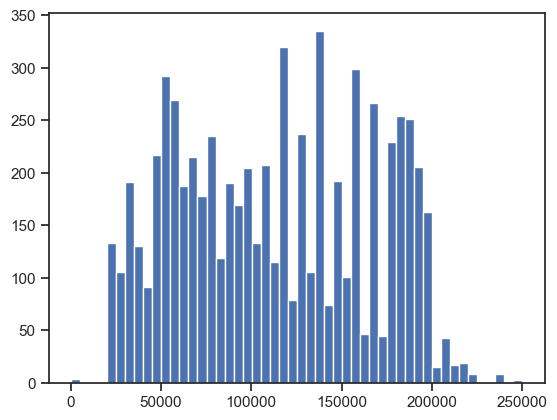

In [229]:
plt.hist(data['Salary'], 50)
plt.show()

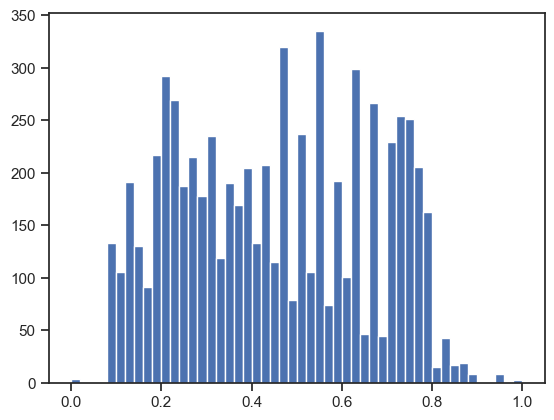

In [230]:
plt.hist(sc1_data, 50)
plt.show()

## Масштабирование данных на основе [Z-оценки](https://ru.wikipedia.org/wiki/Z-%D0%BE%D1%86%D0%B5%D0%BD%D0%BA%D0%B0) - [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler)

In [231]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Age']])

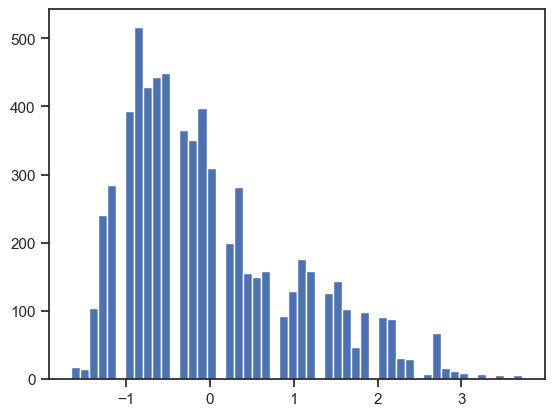

In [232]:
plt.hist(sc2_data, 50)
plt.show()

# Дополнительные источники
- [Руководство scikit-learn по предобработке данных](https://scikit-learn.org/stable/modules/preprocessing.html)
- [Kaggle Data Cleaning Challenge: Handling missing values (упражнения с пояснениями по обработке пропущенных значений и масштабированию признаков)](https://www.kaggle.com/rtatman/data-cleaning-challenge-handling-missing-values)
- [Краткое руководство по категориальным признакам](https://towardsdatascience.com/encoding-categorical-features-21a2651a065c)